In [1]:
import numpy as np
import copy
import math
import time
import sympy as sp

from Simulator_Functions import *
from mec_topo import *

In [2]:
# NOTE: If you want to generate the mechanism collected in mec_topo, please enter the mec_label or mec_name, and change JC and JA matrix to initialize the joints' coordinates
# NOTE: If you want to generate mechanisms that is not in mec_topo, please define your own JJ, JT, JC, JA. Other topology hasen't been fully tested yet, so you might occur error

# please input the mec_label or mec_name, take reference from mec_typo for 1-dof mec

Root_accuracy = 1e-5 # set up accuracy for the calculated result
mec_label = 10  # take RSUR as an example

name_to_label = {name: i for i, name in enumerate(Mechanism.keys())}
label_to_name = {i: name for name, i in name_to_label.items()}

mec_name = label_to_name[mec_label]
print("__________________________________________")
print("Start:",mec_label, mec_name)
m = Mechanism[mec_name]
Actuator = 0 # Put the actuator at J0
JJ = m["JJ"]
JT = m["JT"]
JC = m["JC"]
JA = m["JA"]

if (JJ != (np.transpose(JJ)) ).all():
    print ("Joint-to-Joint matrix is wrong.")


__________________________________________
Start: 10 RURS


In [3]:
# The JC and JA below are from an RSUR example
JC = np.array([[ 0.3390,  0.0031, -0.0234],
 [ 0.3642,  0.0842, -0.1616],
 [ 0.3561, -0.0697, -0.1289],
 [ 0.2088, -0.0288,  0.0127]])

JA = np.array([[[-0.9854, 0.0156, -0.1693],
  [ 0.,          0.,          0.       ]],

 [[-0.4428, 0.5044, -0.7413],
  [ 0.,         -0.63015885, -0.77646624]],

 [[-0.3749, 0.4906, -0.7866],
  [ 0.,          -0.8485, -0.5292        ]],

 [[ 0.,          0.,          0.,        ],
  [ 0.,          0.,          0.,        ]]])



        

In [ ]:
JC = np.array([[ -0.64361497,  0.03757476, -0.08535727],
 [-0.6787822 ,  0.04928492, -0.08158239],
 [-0.55092222,  0.01156022, -0.11967364],
 [-0.41708161,  0.03994967, -0.10951761]])

JA = np.array([[[-0.32862216, -0.92599605, -0.18584614],
  [ 0.,          0.,          0.       ]],

 [[-0.26031982, -0.48806546, -0.38363438],
  [  0.,          0.,          0.,        ]],

 [[-0.1721004 , -0.38816787, -0.84474798],
  [ 0.,          0.,          0.,        ]],

 [[ 0.,          0.,          0.,        ],
  [ 0.,          0.,          0.,        ]]])

In [4]:
# Calculate the configuration
Bi_links, Tri_links, Ground_link, Ground_inx, Actuate_link, Actuate_inx = find_link(JJ, JT, Actuator)
LJ = find_link_joint_table(JJ, Bi_links, Tri_links)
UN = generate_unknown_table(JJ)
Bi_link_len, Bi_link_ang= compute_bi_link_length_angle (LJ, JT, Bi_links, JC, JA)
Tri_link_len, Tri_link_ang = compute_tri_link_length_angle (LJ, JT, Tri_links, JC, JA)
Spacial_p_ang = compute_p_angle(JT, Bi_links, Tri_links, JC, JA)
Type_angle = compute_type_angle(JT, JA)


step = 360
path_data = np.zeros((27, step, 3))

Step_para, Step_actuated_link = Open_curve_simulation (JJ, JT, JC, JA, Actuator, step, Root_accuracy)
for i in range(len(Step_para)):
    Ref_pos_1, Ref_pos_2, Ref_axis = Rigid_ref(mec_name, Step_para[i], Step_actuated_link[i])
    Step_path = RigidbodyMesh(Ref_pos_1, Ref_pos_2, Ref_axis)
    for j in range(27):
        path_data[j, i, :] = Step_path[j,:] 

flipped at: 163


In [6]:
temp_len = i

In [7]:
Coupler = np.zeros((temp_len,27,3)) 
for i in range(temp_len):
    #Ref_pos_1, Ref_pos_2, Ref_axis = Step_actuated_link[i,0], Step_para[i,0:3], Step_actuated_link[i,1]
    Ref_pos_1, Ref_pos_2, Ref_axis = Step_para[i,0:3],Step_actuated_link[i,0], Step_para[i,6:9],
    Coupler[i] = RigidbodyMesh(Ref_pos_1, Ref_pos_2, Ref_axis)

In [8]:
########### Plot function #################
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import directed_hausdorff
from scipy.interpolate import splprep, splev

def plotLine3D(P1,P2, color='gray',linewidth=2,alpha=1):
    ax.plot3D([P1[0],P2[0]], [P1[1],P2[1]], [P1[2],P2[2]],linewidth=linewidth, color=color, alpha=alpha)

def plotMec(jt, jc, ja, bi_links, tri_links, ground_link, coupler, scale=0.5):
    for i in range(len(jt)):
        if jt[i] == 0 or jt[i] == 1: # R, P, C joint
            ax.plot3D([jc[i,0], jc[i,0]+scale*ja[i,0,0]], [jc[i,1], jc[i,1]+scale*ja[i,0,1]], [jc[i,2], jc[i,2]+scale*ja[i,0,2]],linewidth=2, color='blue') 
            ax.plot3D([jc[i,0], jc[i,0]-scale*ja[i,0,0]], [jc[i,1], jc[i,1]-scale*ja[i,0,1]], [jc[i,2], jc[i,2]-scale*ja[i,0,2]],linewidth=2, color='blue')  

            ax.plot3D([jc[i,0], jc[i,0]+0.3*scale*ja[i,0,0]], [jc[i,1], jc[i,1]+0.3*scale*ja[i,0,1]], [jc[i,2], jc[i,2]+0.3*scale*ja[i,0,2]],linewidth=6, color='blue') 
            ax.plot3D([jc[i,0], jc[i,0]-0.3*scale*ja[i,0,0]], [jc[i,1], jc[i,1]-0.3*scale*ja[i,0,1]], [jc[i,2], jc[i,2]-0.3*scale*ja[i,0,2]],linewidth=6, color='blue')  

        elif jt[i] == 3: # C joint
            ax.plot3D([jc[i,0], jc[i,0]+scale*ja[i,0,0]], [jc[i,1], jc[i,1]+scale*ja[i,0,1]], [jc[i,2], jc[i,2]+scale*ja[i,0,2]],linewidth=2, color='magenta') 
            ax.plot3D([jc[i,0], jc[i,0]-scale*ja[i,0,0]], [jc[i,1], jc[i,1]-scale*ja[i,0,1]], [jc[i,2], jc[i,2]-scale*ja[i,0,2]],linewidth=2, color='magenta')  

            ax.plot3D([jc[i,0], jc[i,0]+0.3*scale*ja[i,0,0]], [jc[i,1], jc[i,1]+0.3*scale*ja[i,0,1]], [jc[i,2], jc[i,2]+0.3*scale*ja[i,0,2]],linewidth=6, color='magenta') 
            ax.plot3D([jc[i,0], jc[i,0]-0.3*scale*ja[i,0,0]], [jc[i,1], jc[i,1]-0.3*scale*ja[i,0,1]], [jc[i,2], jc[i,2]-0.3*scale*ja[i,0,2]],linewidth=6, color='magenta')  

        elif jt[i] == 2: # U joint
            ax.plot3D([jc[i,0], jc[i,0]+scale*ja[i,0,0]], [jc[i,1], jc[i,1]+scale*ja[i,0,1]], [jc[i,2], jc[i,2]+scale*ja[i,0,2]],linewidth=2, color='red') 
            ax.plot3D([jc[i,0], jc[i,0]-scale*ja[i,0,0]], [jc[i,1], jc[i,1]-scale*ja[i,0,1]], [jc[i,2], jc[i,2]-scale*ja[i,0,2]],linewidth=2, color='red')  
            
            ax.plot3D([jc[i,0], jc[i,0]+scale*ja[i,1,0]], [jc[i,1], jc[i,1]+scale*ja[i,1,1]], [jc[i,2], jc[i,2]+scale*ja[i,1,2]],linewidth=2, color='orange') 
            ax.plot3D([jc[i,0], jc[i,0]-scale*ja[i,1,0]], [jc[i,1], jc[i,1]-scale*ja[i,1,1]], [jc[i,2], jc[i,2]-scale*ja[i,1,2]],linewidth=2, color='orange')  

            
            ax.plot3D([jc[i,0], jc[i,0]+0.3*scale*ja[i,0,0]], [jc[i,1], jc[i,1]+0.3*scale*ja[i,0,1]], [jc[i,2], jc[i,2]+0.3*scale*ja[i,0,2]],linewidth=6, color='red') 
            ax.plot3D([jc[i,0], jc[i,0]-0.3*scale*ja[i,0,0]], [jc[i,1], jc[i,1]-0.3*scale*ja[i,0,1]], [jc[i,2], jc[i,2]-0.3*scale*ja[i,0,2]],linewidth=6, color='red')  
            
            ax.plot3D([jc[i,0], jc[i,0]+0.3*scale*ja[i,1,0]], [jc[i,1], jc[i,1]+0.3*scale*ja[i,1,1]], [jc[i,2], jc[i,2]+0.3*scale*ja[i,1,2]],linewidth=6, color='orange') 
            ax.plot3D([jc[i,0], jc[i,0]-0.3*scale*ja[i,1,0]], [jc[i,1], jc[i,1]-0.3*scale*ja[i,1,1]], [jc[i,2], jc[i,2]-0.3*scale*ja[i,1,2]],linewidth=6, color='orange')  

        elif jt[i] == 4: # S joint
            ax.scatter3D(jc[i,0],jc[i,1],jc[i,2],marker='o',linewidths=3, color='green')
        
        elif jt[i] == 6: # W joint
            ax.scatter3D(jc[i,0],jc[i,1],jc[i,2],marker='o',linewidths=2, color='black')
    
    for i in range(len(bi_links)):
        inx0, inx1 = bi_links[i,0], bi_links[i,1]
        plotLine3D(jc[inx0],jc[inx1], color='green')

    for i in range(len(tri_links)):
        inx0, inx1, inx2 = tri_links[i,0], tri_links[i,1], tri_links[i,2]
        plotLine3D(jc[inx0],jc[inx1], color='cyan')
        plotLine3D(jc[inx1],jc[inx2], color='cyan')
    
    ground_inx0, ground_inx1 = ground_link[0], ground_link[1]
    plotLine3D(jc[ground_inx0],jc[ground_inx1], color='black',linewidth=3)
    ax.scatter3D(coupler[0],coupler[1],coupler[2],marker='o',linewidths=0.1, color='orange')
    
def plotPath(Pts, limit=5, color = 'gray',linestyle = 'line1', dot_size = 1):
        
    if linestyle == 'line1':
        xline=Pts[:,0]
        yline=Pts[:,1]
        zline=Pts[:,2]
        xline = np.append(xline,xline[0])
        yline = np.append(yline,yline[0])
        zline = np.append(zline,zline[0])
        ax.plot3D(xline, yline, zline, color)
    if linestyle == 'line1_open':
        xline=Pts[:,0]
        yline=Pts[:,1]
        zline=Pts[:,2]
        ax.plot3D(xline, yline, zline, color)
    elif linestyle == 'point1':
        ax.scatter3D(Pts[:,0], Pts[:,1], Pts[:,2], c=color, s=dot_size)
#         ax.scatter3D(Pts[0,0], Pts[0,1], Pts[0,2], c='Green', s=dot_size*10)
#         ax.scatter3D(Pts[-1,0], Pts[-1,1], Pts[-1,2], c='Blue', s=dot_size*10)
    elif linestyle == 'point2':
        ax.scatter3D(Pts[0,:], Pts[1,:], Pts[2,:], c=color, s=dot_size)
#         ax.scatter3D(Pts[0,0], Pts[1,0], Pts[2,0], c='Green', s=dot_size*10)
#         ax.scatter3D(Pts[0,-1], Pts[1,-1], Pts[2,-1], c='Blue', s=dot_size*10)
    elif linestyle == 'line2':
        xline=Pts[0,:]
        yline=Pts[1,:]
        zline=Pts[2,:]
        xline = np.append(xline,xline[0])
        yline = np.append(yline,yline[0])
        zline = np.append(zline,zline[0])
        ax.plot3D(xline, yline, zline, color)
    elif linestyle == 'line2_open':
        xline=Pts[0,:]
        yline=Pts[1,:]
        zline=Pts[2,:]
        ax.plot3D(xline, yline, zline, color)
    else:
        print('wrong linesyle')

        
####################################  Animation  Functions  ##############################################################

from vpython import *
def animation_setting (jt, jc, ja, bi_links, tri_links):
    joint = []
    for i in range(len(jt)):
        if jt[i] == 0: # R joint
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(0.5*ja[i,0,0],0.5*ja[i,0,1],0.5*ja[i,0,2]),radius=0.3,color=color.blue))
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(-0.5*ja[i,0,0],-0.5*ja[i,0,1],-0.5*ja[i,0,2]),radius=0.3,color=color.blue))

        elif jt[i] == 1: # P joint
            joint.append(box(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(0.5*ja[i,0,0],0.5*ja[i,0,1],0.5*ja[i,0,2]), length=1, height=0.5, width=0.5, color=color.black))
            joint.append(box(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(0.5*ja[i,0,0],0.5*ja[i,0,1],0.5*ja[i,0,2]),length=1, height=0.5, width=0.5, color=color.black))

        elif jt[i] == 3: # C joint
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(0.3*ja[i,0,0],0.3*ja[i,0,1],0.3*ja[i,0,2]),radius=0.3,color=color.magenta))
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(-0.3*ja[i,0,0],-0.3*ja[i,0,1],-0.3*ja[i,0,2]),radius=0.3,color=color.magenta))
        
        elif jt[i] == 2: # U joint
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(0.5*ja[i,0,0],0.5*ja[i,0,1],0.5*ja[i,0,2]),radius=0.3,color=color.red))
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(-0.5*ja[i,0,0],-0.5*ja[i,0,1],-0.5*ja[i,0,2]),radius=0.3,color=color.red))
            
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(0.5*ja[i,1,0],0.5*ja[i,1,1],0.5*ja[i,1,2]),radius=0.3,color=color.orange))
            joint.append(cylinder(pos=vector(jc[i,0],jc[i,1],jc[i,2]), axis=vector(-0.5*ja[i,1,0],-0.5*ja[i,1,1],-0.5*ja[i,1,2]),radius=0.3,color=color.orange))

        elif jt[i] == 4: # S joint
            joint.append(sphere(pos=vector(jc[i,0],jc[i,1],jc[i,2]),radius=0.3,color=color.green))
        elif jt[i] == 6: # W joint
            joint.append(sphere(pos=vector(jc[i,0],jc[i,1],jc[i,2]),radius=0.15,color=color.black))
            
    link = []
    for i in range(len(bi_links)):
        inx0, inx1 = bi_links[i,0], bi_links[i,1]
        temp_vector = -vector(jc[inx0,0],jc[inx0,1],jc[inx0,2]) + vector(jc[inx1,0],jc[inx1,1],jc[inx1,2])
        link.append(cylinder(pos=vector(jc[inx0,0],jc[inx0,1],jc[inx0,2]), axis=temp_vector, radius=0.15, color=color.purple))

    for i in range(len(tri_links)):
        inx0, inx1, inx2 = tri_links[i,0], tri_links[i,1], tri_links[i,2]
        temp_vector = -vector(jc[inx0,0],jc[inx0,1],jc[inx0,2]) + vector(jc[inx1,0],jc[inx1,1],jc[inx1,2])
        link.append(cylinder(pos=vector(jc[inx0,0],jc[inx0,1],jc[inx0,2]), axis=temp_vector, radius=0.15, color=color.cyan))
        
        if jt[inx2] == 3: # C joint

            #temp_vector = -vector(jc[inx2,0],jc[inx2,1],jc[inx2,2]) + vector(jc[inx1,0],jc[inx1,1],jc[inx1,2])
            temp_vector = 2*(vector(ja[inx2,0,0], ja[inx2,0,1], ja[inx2,0,2]))
            link.append(cylinder(pos=vector(jc[inx2,0],jc[inx2,1],jc[inx2,2]), axis=temp_vector*3, radius=0.15, color=color.cyan))
            link.append(cylinder(pos=vector(jc[inx2,0],jc[inx2,1],jc[inx2,2]), axis=-temp_vector*3, radius=0.15, color=color.cyan))
        elif jt[inx2] == 1: # P joint

            #temp_vector = -vector(jc[inx2,0],jc[inx2,1],jc[inx2,2]) + vector(jc[inx1,0],jc[inx1,1],jc[inx1,2])
            temp_vector = 2*(vector(ja[inx2,0,0], ja[inx2,0,1], ja[inx2,0,2]))
            link.append(box(pos=vector(jc[inx2,0],jc[inx2,1],jc[inx2,2]), axis=temp_vector, length=10, height=0.25, width=0.25, color=color.cyan))
            link.append(box(pos=vector(jc[inx2,0],jc[inx2,1],jc[inx2,2]), axis=temp_vector, length=10, height=0.25, width=0.25, color=color.cyan))
             
        
    return joint, link

def find_unknowns_inx(ground_link, ground_inx, actuate_link, jt, bi_links):
    joint_inx = [] # [joint inx]
    axis_inx = [] # [joint inx, axis inx]
    for i in range(len(jt)):
        if (i == ground_link[0]) or (i == ground_link[1]): # skip ground link except the axis of u joint
            if jt[i] == 2:
                for j in range(len(bi_links)):
                    if bi_links[j,0] == i or bi_links[j,1] == i: 
                        if ground_inx > j: #u已被用过，地杆占角u_2， u_1未知
                            axis_inx.append(np.array([i,0]))
                        else:
                            axis_inx.append(np.array([i,1]))
                        break

            else:
                continue
                
        elif i == actuate_link[1]: #skip the actuated link except the axis of u joint
            if jt[i] == 2:
                axis_inx.append(np.array([i,1]))
            else:
                continue
                
        elif (len(actuate_link) == 3) and (i == actuate_link[2]): # if the actuated link is a tri_link, then the unkown will be the position of c or p joint
            #while the c/p joint's axis will be known
            "it's risky here because if len(actuate_link)=2, then actuate_link[2] won't exist. But it seems python will calculate"
            "the part before and first..."
            #if i == actuate_link[2]:
            #print("skip:",i)
            joint_inx.append(i)
                           
        elif jt[i] == 2: #u
            joint_inx.append(i)
            axis_inx.append(np.array([i,0]))
            axis_inx.append(np.array([i,1]))

        elif jt[i] == 6 or jt[i] == 4: # w or s
            joint_inx.append(i)
        else:
            joint_inx.append(i)
            axis_inx.append(np.array([i,0]))
            
    joint_inx = np.array(joint_inx)
    axis_inx = np.array(axis_inx)
    return joint_inx, axis_inx

def animation_update_jc_ja (actuate_link, an_update_joint, an_update_axis, jc, ja, step_para, step_actuated_link):
    an_updated_jc = copy.deepcopy(jc)
    an_updated_ja = copy.deepcopy(ja)
    inx = 0
    
    joint_inx = 0
    for i in range(len(jc)): # go through all joints one by one
        if joint_inx < len(an_update_joint):
            if an_update_joint[joint_inx] == i: # if joint i needs to be updated
                an_updated_jc[i] = step_para[inx:inx+3]
                joint_inx += 1
                inx += 3
        for j in range(len(an_update_axis)):
            if an_update_axis[j,0] == i:
                if an_update_axis[j,1] == 0:
                    an_updated_ja[i,0] = step_para[inx:inx+3]
                    inx += 3
                if an_update_axis[j,1] == 1:
                    an_updated_ja[i,1] = step_para[inx:inx+3]
                    inx += 3
                    
    an_updated_jc[actuate_link[1]] = step_actuated_link[0]
    an_updated_ja[actuate_link[1],0] = step_actuated_link[1]
    if len(actuate_link)==3:
        an_updated_ja[actuate_link[2],0] = step_actuated_link[2]

    return an_updated_jc, an_updated_ja

def animation_update (an_joint, an_link, jt, up_jc, up_ja, bi_links, tri_links):
    joint_inx = 0
    for i in range(len(jt)):
        if jt[i] == 0 or jt[i] == 1: # R, P joint
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(0.5*up_ja[i,0,0],0.5*up_ja[i,0,1],0.5*up_ja[i,0,2])
            joint_inx += 1
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(-0.5*up_ja[i,0,0],-0.5*up_ja[i,0,1],-0.5*up_ja[i,0,2])
            joint_inx += 1
#             print("r or p", joint_inx)
            
        elif jt[i] == 1: # P joint
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(0.5*up_ja[i,0,0],0.5*up_ja[i,0,1],0.5*up_ja[i,0,2])
            an_joint[joint_inx].length = 1
            joint_inx += 1
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(-0.5*up_ja[i,0,0],-0.5*up_ja[i,0,1],-0.5*up_ja[i,0,2])
            an_joint[joint_inx].length = 1
            joint_inx += 1
        
        elif jt[i] == 2: # U joint
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(0.5*up_ja[i,0,0],0.5*up_ja[i,0,1],0.5*up_ja[i,0,2])            
            joint_inx += 1
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(-0.5*up_ja[i,0,0],-0.5*up_ja[i,0,1],-0.5*up_ja[i,0,2])            
            joint_inx += 1
#             print("u1", joint_inx)
            
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(0.5*up_ja[i,1,0],0.5*up_ja[i,1,1],0.5*up_ja[i,1,2])            
            joint_inx += 1       
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(-0.5*up_ja[i,1,0],-0.5*up_ja[i,1,1],-0.5*up_ja[i,1,2])            
            joint_inx += 1 
#             print("u2", joint_inx)
            
        elif jt[i] == 3: # C joint
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(0.3*up_ja[i,0,0],0.3*up_ja[i,0,1],0.3*up_ja[i,0,2])
            joint_inx += 1
            an_joint[joint_inx].pos =vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            an_joint[joint_inx].axis = vector(-0.3*up_ja[i,0,0],-0.3*up_ja[i,0,1],-0.3*up_ja[i,0,2])
            joint_inx += 1
#             print("c", joint_inx)

        elif jt[i] == 4: # S joint
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            joint_inx += 1 
#             print("s", joint_inx)
        elif jt[i] == 6: # W joint
            an_joint[joint_inx].pos = vector(up_jc[i,0],up_jc[i,1],up_jc[i,2])
            joint_inx += 1 
#             print("w", joint_inx)
            
    link_inx = 0
    for i in range(len(bi_links)):
        inx0, inx1 = bi_links[i,0], bi_links[i,1]
        temp_vector = -vector(up_jc[inx0,0],up_jc[inx0,1],up_jc[inx0,2]) + vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
        an_link[link_inx].pos = vector(up_jc[inx0,0],up_jc[inx0,1],up_jc[inx0,2])
        an_link[link_inx].axis = temp_vector
        link_inx += 1
        
    for i in range(len(tri_links)):
        inx0, inx1, inx2 = tri_links[i,0], tri_links[i,1], tri_links[i,2]
        temp_vector = -vector(up_jc[inx0,0],up_jc[inx0,1],up_jc[inx0,2]) + vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
        an_link[link_inx].pos = vector(up_jc[inx0,0],up_jc[inx0,1],up_jc[inx0,2])
        an_link[link_inx].axis = temp_vector
        link_inx += 1
        
        if jt[inx2] == 3: # C joint
        #temp_vector = -vector(up_jc[inx2,0],up_jc[inx2,1],up_jc[inx2,2]) + vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
            temp_vector = 2*(vector(up_ja[inx2,0,0], up_ja[inx2,0,1], up_ja[inx2,0,2]))
            an_link[link_inx].pos = vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
            an_link[link_inx].axis = 3*temp_vector
            link_inx += 1

            an_link[link_inx].pos = vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
            an_link[link_inx].axis = -3*temp_vector
            link_inx += 1
        
        elif jt[inx2] == 1: # P joint
        #temp_vector = -vector(up_jc[inx2,0],up_jc[inx2,1],up_jc[inx2,2]) + vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
            temp_vector = 2*(vector(up_ja[inx2,0,0], up_ja[inx2,0,1], up_ja[inx2,0,2]))
            an_link[link_inx].pos = vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
            an_link[link_inx].axis = temp_vector
            an_link[link_inx].length = 20
            link_inx += 1

            an_link[link_inx].pos = vector(up_jc[inx1,0],up_jc[inx1,1],up_jc[inx1,2])
            an_link[link_inx].axis = -temp_vector
            an_link[link_inx].length = 20
            link_inx += 1
    return an_joint, an_link

<IPython.core.display.Javascript object>

In [9]:
%matplotlib notebook

In [ ]:
Coupler.shape

<IPython.core.display.Javascript object>


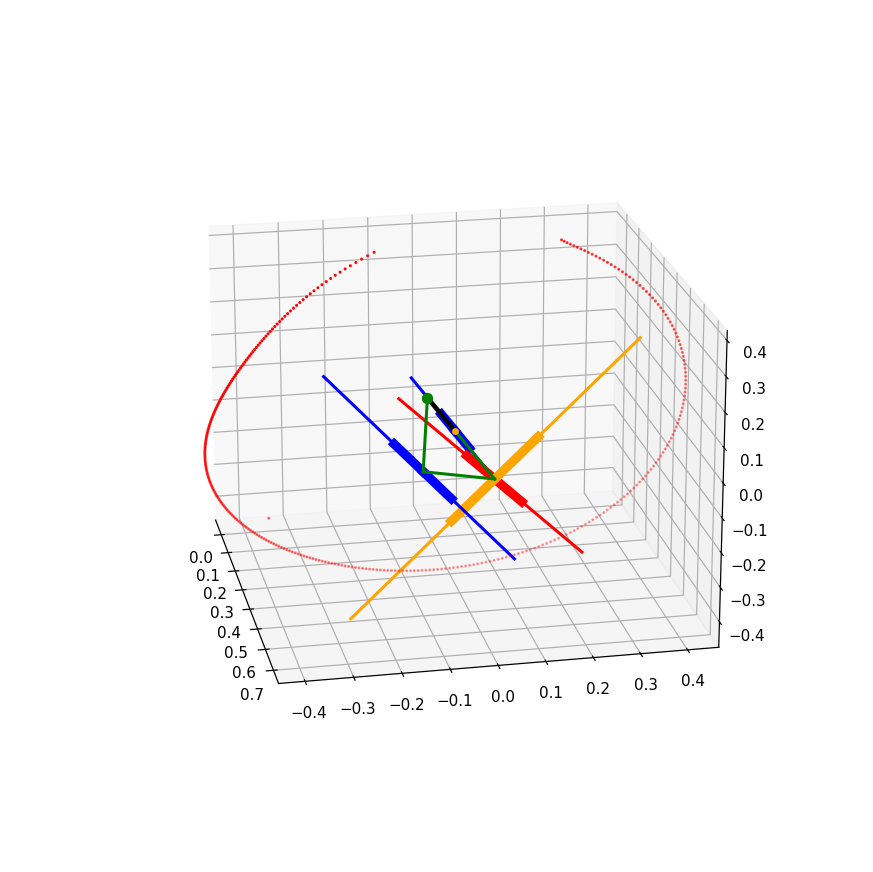

0


In [10]:
inxt = 0
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(1, 1, 1, projection='3d')
plotMec(JT, JC, JA, Bi_links, Tri_links, Ground_link, JC[0] ,scale=0.5)
#plotPath(Step_para,color = 'red',linestyle = 'line1')
plotPath(Coupler[:,0],color = 'red',linestyle = 'point1')
print(inxt)

In [15]:
scene = canvas(width=800,height=500,center=vector(0,0,0),background=color.white);

an_Joint, an_Link = animation_setting (JT, JC, JA, Bi_links, Tri_links)
an_Update_joint, an_Update_axis = find_unknowns_inx(Ground_link, Ground_inx, Actuate_link, JT, Bi_links)

        

<IPython.core.display.Javascript object>

In [16]:
while True:
    for i in range(0,len(Step_para)):
        #print(i)
        rate(20)
        an_Update_jc, an_Update_ja = animation_update_jc_ja (Actuate_link, an_Update_joint, an_Update_axis, JC, JA, Step_para[i],Step_actuated_link[i])
        #print(an_Update_jc)
        animation_update(an_Joint, an_Link, JT, an_Update_jc, an_Update_ja, Bi_links, Tri_links)

KeyboardInterrupt: 